## Weather Data

In this notebook, we process the weather data. The data, contained in the paths "Data/ghcnd-stations.txt" and "Data/ghcnd_all.tar.gz", is obtained from the following link.

https://www.ncei.noaa.gov/pub/data/ghcn/daily/

We will consider the temperature, precipitation, and snowfall in regions enclosed by a grid.

### Importing the necessary modules

In [4]:
import pandas as pd
import numpy as np
import datetime
import tarfile
import re
import math
import seaborn as sns
import matplotlib.pyplot as plt
import time

We will use the printer class and the idisplay class to track the progress information while the notebook is running.

In [6]:
from io import StringIO
from IPython import display

class printer(str):
    def __repr__(self):
       return self

class idisplay:
    def __init__(self,str):
        self.myobject = display.display(printer(str), display_id=True)
        
    def update(self,str):
        return self.myobject.update(printer(str))

### Necessary functions to read the data

The read_station_metadata function will allow us to read the data in "Data/ghcnd-stations.txt". 
The format of the data is as follows.


| Variable | Columns | Type |
| :---: | :---: | :---: |
| ID | 1-11 | Character |
| LATITUDE | 13-20 | Float |
| LONGITUDE | 22-30 | Float |
| ELEVATION | 32-37 | Float |
| STATE | 39-40 | Character |
| NAME | 42-71 | Character |
| GSN FLAG | 73-75 | Character |
| HCN/CRN FLAG | 77-79 | Character |
| WMO ID | 81-85 | Character |

The code was obtained from https://gitlab.com/-/snippets/1838910.

In [9]:
metadata_col_specs = [
    (0,  12),
    (12, 21),
    (21, 31),
    (31, 38),
    (38, 41),
    (41, 72),
    (72, 76),
    (76, 80),
    (80, 86)
]



metadata_names = [
    "ID",
    "LATITUDE",
    "LONGITUDE",
    "ELEVATION",
    "STATE",
    "NAME",
    "GSN FLAG",
    "HCN/CRN FLAG",
    "WMO ID"
]


metadata_dtype = {
    "ID": str,
    "STATE": str,
    "NAME": str,
    "GSN FLAG": str,
    "HCN/CRN FLAG": str,
    "WMO ID": str
}




def read_station_metadata(filename="ghcnd-stations.txt"):
    """Reads in station metadata

    :filename: ghcnd station metadata file.
    :returns: station metadata as a pandas Dataframe

    """
    df = pd.read_fwf(filename, colspecs = metadata_col_specs, names=metadata_names, dtype=metadata_dtype)

    return df

The read_ghcn_data_file function will allow us to read the data contained in the .dly files in "Data/ghcnd_all.tar.gz". 
The format of the data is as follows.


| Variable | Columns | Type |
| :---: | :---: | :---: |
| ID | 1-11 | Character |
| YEAR | 12-15 | Integer |
| MONTH | 16-17 | Integer |
| ELEMENT | 18-21 | Character |
| VALUE1 | 22-26 | Integer |
| MFLAG1 | 27-27 | Character |
| QFLAG1 | 28-28 | Character |
| SFLAG1 | 29-29 | Character |
| VALUE2 | 30-34 | Integer |
| ... | ... | ... |
| VALUE31 | 262-266 | Integer |
| MFLAG31 | 267-267 | Character |
| QFLAG31 | 268-268 | Character |
| SFLAG31 | 269-269 | Character |

The code was obtained from https://gitlab.com/-/snippets/1838910 and was slightly adjusted.

In [11]:
data_header_names = [
    "ID",
    "YEAR",
    "MONTH",
    "ELEMENT"]

data_header_col_specs = [
    (0,  11),
    (11, 15),
    (15, 17),
    (17, 21)]

data_header_dtypes = {
    "ID": str,
    "YEAR": int,
    "MONTH": int,
    "ELEMENT": str}

data_col_names = [[
    "VALUE" + str(i + 1),
    "MFLAG" + str(i + 1),
    "QFLAG" + str(i + 1),
    "SFLAG" + str(i + 1)]
    for i in range(31)]

# Join sub-lists
data_col_names = sum(data_col_names, [])

data_replacement_col_names = [[
    ("VALUE", i + 1),
    ("MFLAG", i + 1),
    ("QFLAG", i + 1),
    ("SFLAG", i + 1)]
    for i in range(31)]

# Join sub-lists
data_replacement_col_names = sum(data_replacement_col_names, [])
data_replacement_col_names = pd.MultiIndex.from_tuples(
    data_replacement_col_names,
    names=['VAR_TYPE', 'DAY'])

data_col_specs = [[
    (21 + i * 8, 26 + i * 8),
    (26 + i * 8, 27 + i * 8),
    (27 + i * 8, 28 + i * 8),
    (28 + i * 8, 29 + i * 8)]
    for i in range(31)]
data_col_specs = sum(data_col_specs, [])

data_col_dtypes = [{
    "VALUE" + str(i + 1): int,
    "MFLAG" + str(i + 1): str,
    "QFLAG" + str(i + 1): str,
    "SFLAG" + str(i + 1): str}
    for i in range(31)]


data_header_dtypes.update({k: v for d in data_col_dtypes for k, v in d.items()})



def read_ghcn_data_file(filename, include_flags=False):
    """Reads in all data from a GHCN .dly data file

    :param filename: path to file
    :param variables: list of variables to include in output dataframe
        e.g. ['TMAX', 'TMIN', 'PRCP']
    :param include_flags: Whether to include data quality flags in the final output
    :returns: Pandas dataframe
    """


    df = pd.read_fwf(
        filename,
        colspecs=data_header_col_specs + data_col_specs,
        names=data_header_names + data_col_names,
        index_col=data_header_names,
        dtype=data_header_dtypes
        )

   
    df.columns = data_replacement_col_names

    if not include_flags:
        df = df.loc[:, ('VALUE', slice(None))]
        df.columns = df.columns.droplevel('VAR_TYPE')


    
    df = df.stack(level='DAY').unstack(level='ELEMENT').reset_index(level = ("ID",))

    
    df.replace(-9999.0, np.nan, inplace=True)

    df = df.loc[(df.index.get_level_values("YEAR")>=2018) & (df.index.get_level_values("YEAR")<=2019)]
    
    return df[df.columns.intersection(['SNOW', 'PRCP', 'TOBS'])]


### Reading the data into a Pandas DataFrame

In [13]:
# Opening up our tar file

tar = tarfile.open("Data/ghcnd_all.tar.gz","r:gz")
allmembers = tar.getmembers()

The name of the members in the tar file are of the form "ghcnd_all/(Station Name).dly" (except for the first and last member).
We will use Regular expressions to obtain all the names of the weather stations.
The Pandas series stationNames contains all the names inside the list allmembers, and the indices are the positions of the corresponding element in the list allmembers.

In [15]:
temp = list(map(lambda x: re.search("(?<=\/)(.+)(?=\.)",x.name).group(0), allmembers[1:-1]))
stationNames = pd.Series(data = temp, index = np.arange(len(temp)) + 1)

print(stationNames.head(5))

1    ASN00012033
2    ASN00012034
3    ASN00012035
4    ASN00012036
5    ASN00012037
dtype: object


For this project, we only care about the region defined by the lat-long restrictions in the first 4 lines of this cell. This finds the stations in that region. We will round down the latitude and longitude to the nearest half integer.

In [17]:
lat_min = 38
lat_max = 45
long_min = -90
long_max = -83

station_data = read_station_metadata("Data/ghcnd-stations.txt")
station_data["LATITUDE"] = np.floor(station_data["LATITUDE"]) 
station_data["LONGITUDE"] = np.floor(station_data["LONGITUDE"]) 
station_data = station_data[(station_data["LATITUDE"] < lat_max) & (station_data["LATITUDE"] >= lat_min) & (station_data["LONGITUDE"] >= long_min) & (station_data["LONGITUDE"] < long_max)]
valid_stations =  stationNames.isin(station_data["ID"].to_numpy())
valid_stations = valid_stations.loc[valid_stations == True].index.tolist()

Finally, we aggregate the weather data from the weather stations based on the day the data was observed and the location where it was observed.

In [19]:
print("You have "+str(len(valid_stations))+" stations!")
console = idisplay("Let's start!")

win_count = 0

cols = ["PRCP", "PRCP_CNT", "SNOW", "SNOW_CNT", "TOBS", "TOBS_CNT"]
inds = pd.MultiIndex.from_product([[2018, 2019], 
                                  [i+1 for i in range(12)], 
                                  [i+1 for i in range(31)], 
                                  [lat_min + i for i in range(lat_max-lat_min)],
                                  [long_min + i for i in range(long_max - long_min)]], names = ["YEAR", "MONTH", "DAY", "LATITUDE", "LONGITUDE"])

weather_by_grid = pd.DataFrame(data = None, index = inds, columns = cols)


start = time.perf_counter()

for i in range(len(valid_stations)):
    index = valid_stations[i]
    addend = read_ghcn_data_file(StringIO(tar.extractfile(allmembers[index]).read().decode('utf-8')))
    name = stationNames.loc[index]
    my_station_data = station_data.loc[station_data["ID"]==name].iloc[0]
    addend["LATITUDE"]= my_station_data["LATITUDE"]
    addend["LONGITUDE"]= my_station_data["LONGITUDE"]
    addend = addend.set_index(["LATITUDE","LONGITUDE"],append=True)
    addend = addend[addend.columns.intersection(["PRCP", "SNOW", "TOBS"])]
    for j in addend.columns:
        addend[j+'_CNT']=addend[j].apply(lambda a : int(not math.isnan(a)))

    
    weather_by_grid = weather_by_grid.add(addend,fill_value = 0)
    win_count+=1
    console.update(str(valid_stations[i])+" "+str(win_count)+" "+str(weather_by_grid.size))

console.update("You've scraped "+str(win_count)+" stations; done!")


end = time.perf_counter()


print(f'Time elapsed: {end - start} seconds')

You have 6420 stations!


You've scraped 6420 stations; done!

Time elapsed: 1207.6842459000181 seconds


In [20]:
for j in ["PRCP", "SNOW", "TOBS"]:
    weather_by_grid = weather_by_grid[weather_by_grid[j+"_CNT"] > 0]
    weather_by_grid[j] = weather_by_grid[j] / weather_by_grid[j + "_CNT"]

weather_by_grid = weather_by_grid[["PRCP", "SNOW", "TOBS"]]

# the temperature is recorded in tenths of a celsius

weather_by_grid["TOBS"] = weather_by_grid["TOBS"] / 10

In [21]:
print(weather_by_grid.info())
print(weather_by_grid.head())

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 35768 entries, (2018, 1, 1, 38, -90) to (2019, 12, 31, 44, -84)
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   PRCP    35768 non-null  object
 1   SNOW    35768 non-null  object
 2   TOBS    35768 non-null  object
dtypes: object(3)
memory usage: 1015.7+ KB
None
                                  PRCP SNOW       TOBS
YEAR MONTH DAY LATITUDE LONGITUDE                     
2018 1     1   38       -90        0.0  0.0 -18.166667
                        -89        0.0  0.0 -19.185714
                        -88        0.0  0.0 -15.716667
                        -87        0.0  0.0      -18.9
                        -86        0.0  0.0      -15.4


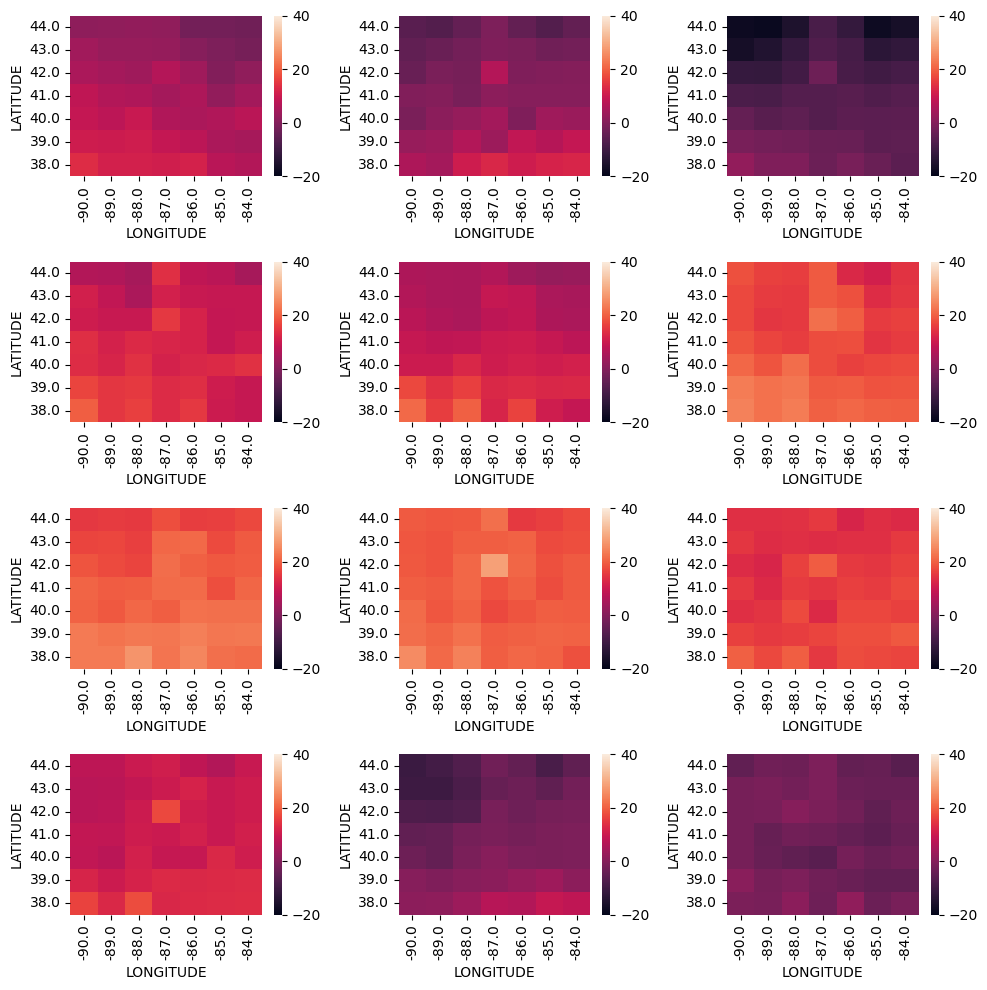

In [22]:
# See some of the data we've put into weather_by_grid!

pd.set_option('display.min_rows',100)
pd.set_option('display.max_rows',100)

fig, axes = plt.subplots(nrows=4,ncols=3,figsize=(10,10))

for i in range(1,13):
    wg = weather_by_grid
    wg = wg[wg.index.isin([2019], level="YEAR")]
    wg = wg[wg.index.isin([i], level="MONTH")]
    wg= wg[wg.index.isin([7], level="DAY")]
    wg = wg.reset_index(level="LATITUDE").reset_index(level="LONGITUDE")

    wg = wg.astype(float)
    
    wg = pd.pivot_table(wg,values='TOBS',
                        index="LATITUDE",
                        columns="LONGITUDE")
    
    sns.heatmap(wg,ax=axes[math.floor((i-1)/3)][(i-1)%3],vmin=-20,vmax=40).invert_yaxis()
fig.tight_layout()

In [23]:
# Export our data. Here, to weather_two, named for the number of years of data included

weather_by_grid.to_csv(r'data/weather_two.txt')